# Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import lightgbm as lgb
import geopandas as gpd

from shapely.geometry import Point
from scipy.optimize import minimize
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from math import radians, sin, cos, sqrt, atan2

import add_feature



# Load Dataset and Cleaning

parse data test supaya kolomnya jadi datetime/nama_pos/id dari yang awalnya cmn id doang

In [2]:
# 1. Load raw files
train = pd.read_csv('../data/train.csv', parse_dates=['datetime'])
test_raw = pd.read_csv('../data/test.csv')
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

# 2. Parse kolom 'id' di test.csv -> jadi 'datetime' dan 'nama_pos'
# format id: "2025-09-19 06:00:00 - Arjowinangun - Pacitan"
# split hanya di kemunculan PERTAMA " - " (karena nama pos bisa mengandung " - " juga)
split_result = test_raw['id'].str.split(' - ', n=1, expand=True)
test = pd.DataFrame({
    'datetime': pd.to_datetime(split_result[0]),
    'nama_pos': split_result[1],
    'id': test_raw['id']   # simpan buat submission nanti
})

# test.to_csv("test_tes.csv", index=False)

print(test['nama_pos'].nunique())  # pastikan tetap 30
print(test.head())

30
             datetime                nama_pos  \
0 2025-09-19 06:00:00  Arjowinangun - Pacitan   
1 2025-09-19 12:00:00  Arjowinangun - Pacitan   
2 2025-09-19 18:00:00  Arjowinangun - Pacitan   
3 2025-09-20 06:00:00  Arjowinangun - Pacitan   
4 2025-09-20 12:00:00  Arjowinangun - Pacitan   

                                             id  
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan  
1  2025-09-19 12:00:00 - Arjowinangun - Pacitan  
2  2025-09-19 18:00:00 - Arjowinangun - Pacitan  
3  2025-09-20 06:00:00 - Arjowinangun - Pacitan  
4  2025-09-20 12:00:00 - Arjowinangun - Pacitan  


gabung semua dataset train dan test untuk persiapan aggregation kolom dengan data lingkungan

In [3]:
train['is_train'] = 1
test['is_train'] = 0
test['tma_mdpl'] = np.nan   # kosongkan target, akan diisi model nanti

full = pd.concat([
    train[['datetime', 'nama_pos', 'tma_mdpl', 'is_train']],
    test[['datetime', 'nama_pos', 'tma_mdpl', 'is_train', 'id']]
], ignore_index=True, sort=False)

full = full.sort_values(['nama_pos', 'datetime']).reset_index(drop=True)
print(full.shape)   # harus = 84396 + 21780
full.head()

# full.to_csv("full_data.csv",index=False)

(106176, 5)


,datetime,nama_pos,tma_mdpl,is_train,id
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN


gabungkan data lingkungan ke data fullnya (+ cleaned dari -999 di solar radiation)

In [4]:
full = pd.read_csv('../data/full_data.csv', parse_dates=['datetime'])
env = pd.read_csv('../data/data_pendukung/data_lingkungan.csv', parse_dates=['datetime'])

# === LANGKAH BARU: bersihkan sentinel -999 SEBELUM agregasi ===
numeric_cols = env.select_dtypes(include='number').columns
for col in numeric_cols:
    n_sentinel = (env[col] == -999).sum()
    if n_sentinel > 0:
        print(f'{col}: {n_sentinel} baris sentinel -999 -> diubah jadi NaN')
        env[col] = env[col].replace(-999, np.nan)

# === LANGKAH LAMA: assign window_end (tidak berubah) ===
hour = env['datetime'].dt.hour
date = env['datetime'].dt.normalize()
conditions = [hour < 6, hour < 12, hour < 18]
choices = [date + pd.Timedelta(hours=6), date + pd.Timedelta(hours=12), date + pd.Timedelta(hours=18)]
default = date + pd.Timedelta(days=1, hours=6)
env['window_end'] = np.select(conditions, choices, default=default)

# === LANGKAH LAMA: agregasi (tidak berubah, tapi hasilnya sekarang aman krn NaN otomatis di-skip oleh sum/mean) ===
agg_dict = {
    'rainfall_mm': 'sum', 'rainfall_openmeteo_mm': 'sum', 'rainfall_max_24h_mm': 'max',
    'humidity_pct': 'mean', 'wind_direction_deg': 'mean', 'dew_point_c': 'mean',
    'cloud_cover_pct': 'mean', 'temperature_c': 'mean', 'wind_speed_kmh': 'mean',
    'solar_radiation_mj_m2': 'sum', 'soil_moisture_0_7cm': 'mean', 'soil_moisture_7_28cm': 'mean',
    'soil_moisture_28_100cm': 'mean', 'soil_moisture_100_255cm': 'mean',
    'surface_pressure_hpa': 'mean', 'pressure_msl_hpa': 'mean', 'built_surface_m2': 'first',
    'landcover_class': 'first', 'landcover_name': 'first', 'rmm1': 'mean', 'rmm2': 'mean',
    'mjo_phase': 'first', 'mjo_amplitude': 'mean', 'mjo_active': 'first', 'nino_34': 'mean',
}
env_agg = env.groupby(['nama_pos', 'window_end']).agg(agg_dict).reset_index()

sum_cols = ['rainfall_mm', 'rainfall_openmeteo_mm', 'solar_radiation_mj_m2']

for col in sum_cols:
    all_nan_mask = env.groupby(['nama_pos', 'window_end'])[col].apply(lambda x: x.isna().all())
    n_affected = all_nan_mask.sum()
    print(f'{col}: {n_affected} window full-NaN -> override balik jadi NaN')
    # all_nan_mask index-nya sama (nama_pos, window_end) dgn env_agg, jadi bisa langsung dipakai buat masking
    env_agg.loc[all_nan_mask.values, col] = np.nan
    
env_agg = env_agg.rename(columns={'window_end': 'datetime'})

full = full.merge(env_agg, on=['nama_pos', 'datetime'], how='left')

# === CEK HASIL ===
print(full['solar_radiation_mj_m2'].describe())   # min sekarang harusnya wajar, tidak lagi -11988
print(full[full['datetime'] >= '2025-12-31'][['solar_radiation_mj_m2','soil_moisture_0_7cm','nino_34']].isna().sum())

# full.to_csv("../data/full_data_merged.csv",index=False)

solar_radiation_mj_m2: 100080 baris sentinel -999 -> diubah jadi NaN
rainfall_mm: 0 window full-NaN -> override balik jadi NaN
rainfall_openmeteo_mm: 0 window full-NaN -> override balik jadi NaN
solar_radiation_mj_m2: 12510 window full-NaN -> override balik jadi NaN
count    93696.000000
mean      1719.582734
std       1338.502936
min          0.000000
25%         14.120000
50%       2084.360000
75%       2836.980000
max       4387.940000
Name: solar_radiation_mj_m2, dtype: float64
solar_radiation_mj_m2    12480
soil_moisture_0_7cm         60
nino_34                   1590
dtype: int64


In [5]:
print("""
    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing

""")


    note: pada tgl 4 feb - 28 feb 2025 itu gaada datanya jadi abis 3 feb langsung ke 1 maret 2025, ntar bakal di bring up
    di preprocessing




## feature engineering

### check dataset gabungan

In [6]:
full.head()

,datetime,nama_pos,tma_mdpl,is_train,id,rainfall_mm,rainfall_openmeteo_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,...,pressure_msl_hpa,built_surface_m2,landcover_class,landcover_name,rmm1,rmm2,mjo_phase,mjo_amplitude,mjo_active,nino_34
0,2023-01-01 06:00:00,Arjowinangun - Pacitan,1.30,1,NaN,0.0,0.0,0.0,86.000000,348.333333,...,1009.066667,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
1,2023-01-01 12:00:00,Arjowinangun - Pacitan,1.20,1,NaN,0.3,0.3,0.2,79.166667,327.666667,...,1010.800000,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
2,2023-01-01 18:00:00,Arjowinangun - Pacitan,1.50,1,NaN,3.6,3.6,1.7,81.666667,296.333333,...,1008.983333,2419.0,10,Tree cover,-0.092299,1.277599,7.0,1.280929,1.0,-0.72
3,2023-01-02 06:00:00,Arjowinangun - Pacitan,1.45,1,NaN,1.0,1.0,1.7,90.250000,316.166667,...,1010.000000,2419.0,10,Tree cover,-0.311643,1.335574,7.0,1.386106,1.0,-0.72
4,2023-01-02 12:00:00,Arjowinangun - Pacitan,1.25,1,NaN,0.6,0.6,1.7,79.500000,298.166667,...,1010.766667,2419.0,10,Tree cover,-0.530987,1.393549,7.0,1.491283,1.0,-0.72


### dropping columns

In [7]:
full.drop([
    "rainfall_openmeteo_mm", # korelasi = 1
], axis=1, inplace=True)

In [8]:
river = gpd.read_file("../data/data_pendukung/HydroRIVERS_v10_au_shp/HydroRIVERS_v10_au.shp")
river = river.to_crs(4326)

print(river.columns)

Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'geometry'],
      dtype='object')


### detect glitches

In [9]:
full = pd.read_csv('../data/full_data_merged.csv', parse_dates=['datetime'])
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

def detect_and_fix_glitches(df, window=4, ratio_threshold=4, zscore_threshold=10, min_abs_jump=1.0):
    df = df.sort_values(['nama_pos','datetime'])  # TANPA reset_index (biar index tetap nyambung ke full)
    glitch_indices = []
    for pos, g in df.groupby('nama_pos'):
        val = g['tma_mdpl'].values
        idx_list = g.index.tolist()
        local_std = np.std(val)
        for i in range(window, len(val)-window):
            neighborhood = np.concatenate([val[i-window:i], val[i+1:i+1+window]])
            local_median = np.median(neighborhood)
            cur_v = val[i]
            jump = abs(cur_v - local_median)
            if jump < min_abs_jump:
                continue
            ratio = max(cur_v/local_median, local_median/cur_v) if cur_v>0 and local_median>0 else 999
            is_extreme = (ratio > ratio_threshold) or (local_std > 0 and (jump/local_std) > zscore_threshold)
            if is_extreme:
                glitch_indices.append(idx_list[i])
    print(f'Ditemukan {len(glitch_indices)} titik glitch')
    df.loc[glitch_indices, 'tma_mdpl'] = np.nan
    df['tma_mdpl'] = df.groupby('nama_pos')['tma_mdpl'].transform(lambda x: x.interpolate(method='linear'))
    return df, glitch_indices

train_part = full[full['is_train']==1].copy()
train_part_fixed, glitch_idx = detect_and_fix_glitches(train_part)
full.loc[train_part_fixed.index, 'tma_mdpl'] = train_part_fixed['tma_mdpl']

Ditemukan 24 titik glitch


### adding features

In [46]:
# full, feature_cols = add_feature.add_features(full, koor)
koor = pd.read_csv('../data/data_pendukung/koordinat_pos.csv')

full.drop(['rainfall_openmeteo_mm'], axis=1, inplace=True, errors="ignore")
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== reindex grid 6-jaman (msh perlu, krn rain/soil_moisture lag-roll butuh alignment waktu) =====
grids = []
for pos, g in full.groupby('nama_pos'):
    full_range = pd.date_range(g['datetime'].min(), g['datetime'].max(), freq='6h')
    full_range = full_range[full_range.hour.isin([6,12,18])]
    grids.append(pd.DataFrame({'nama_pos': pos, 'datetime': full_range}))
grid = pd.concat(grids, ignore_index=True)
full = grid.merge(full, on=['nama_pos','datetime'], how='left')
full['is_phantom'] = full['is_train'].isna().astype(int)
full = full.sort_values(['nama_pos','datetime']).reset_index(drop=True)

# ===== FITUR WAKTU (lebih lengkap) =====
full['hour'] = full['datetime'].dt.hour
full['day'] = full['datetime'].dt.day
full['month'] = full['datetime'].dt.month
full['week'] = full['datetime'].dt.isocalendar().week.astype(int)
full['quarter'] = full['datetime'].dt.quarter
full['dayofyear'] = full['datetime'].dt.dayofyear
full['dayofweek'] = full['datetime'].dt.dayofweek
full['is_weekend'] = full['dayofweek'].isin([5,6]).astype(int)
full['hour_sin'] = np.sin(2*np.pi*full['hour']/24)
full['hour_cos'] = np.cos(2*np.pi*full['hour']/24)
full['month_sin'] = np.sin(2*np.pi*full['month']/12)
full['month_cos'] = np.cos(2*np.pi*full['month']/12)
full['dayofyear_sin'] = np.sin(2*np.pi*full['dayofyear']/365)
full['dayofyear_cos'] = np.cos(2*np.pi*full['dayofyear']/365)

# ===== FITUR CUACA: lag & rolling (SEMUA berbasis cuaca, BUKAN target -> gak butuh recursion) =====
g = full.groupby('nama_pos')

def rollsum(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).sum())
def rollmean(col, n): return g[col].transform(lambda x: x.shift(1).rolling(n).mean())

full['rainfall_mm_lag_1'] = g['rainfall_mm'].shift(1)
full['rainfall_mm_lag_3'] = g['rainfall_mm'].shift(3)
full['rainfall_mm_lag_6'] = g['rainfall_mm'].shift(6)
full['humidity_lag_1'] = g['humidity_pct'].shift(1)
full['soil_moisture_0_7cm_lag_1'] = g['soil_moisture_0_7cm'].shift(1)
full['soil_moisture_7_28cm_lag_1'] = g['soil_moisture_7_28cm'].shift(1)
full['soil_moisture_28_100cm_lag_1'] = g['soil_moisture_28_100cm'].shift(1)
full['soil_moisture_100_255cm_lag_1'] = g['soil_moisture_100_255cm'].shift(1)

full['rainfall_mm_roll_sum_6'] = rollsum('rainfall_mm', 6)
full['rainfall_mm_roll_sum_12'] = rollsum('rainfall_mm', 12)
full['soil_moisture_0_7cm_roll_mean_6'] = rollmean('soil_moisture_0_7cm', 6)
full['soil_moisture_7_28cm_roll_mean_6'] = rollmean('soil_moisture_7_28cm', 6)
full['soil_moisture_28_100cm_roll_mean_6'] = rollmean('soil_moisture_28_100cm', 6)
full['soil_moisture_100_255cm_roll_mean_6'] = rollmean('soil_moisture_100_255cm', 6)

# akumulasi hujan multi-window (48h=8 periode, 96h=16, 144h=24, 168h=28, 336h=56 -- satuan 6 jam-an)
full['rain_cumsum_48h']  = rollsum('rainfall_mm', 8)
full['rain_cumsum_96h']  = rollsum('rainfall_mm', 16)
full['rain_cumsum_144h'] = rollsum('rainfall_mm', 24)
full['rain_cumsum_168h'] = rollsum('rainfall_mm', 28)
full['rain_cumsum_336h'] = rollsum('rainfall_mm', 56)

# indeks iklim: rolling mean jangka panjang (120 & 240 periode 6-jaman = ~30 & ~60 hari)
for col in ['rmm1','rmm2','mjo_amplitude','nino_34']:
    full[f'{col}_roll_mean_120'] = rollmean(col, 120)
    full[f'{col}_roll_mean_240'] = rollmean(col, 240)

full['delta_rain_1'] = g['rainfall_mm'].diff(1)
full['delta_pressure_1'] = g['surface_pressure_hpa'].diff(1)

# =========================================================
# SHOCK / INTENSITY FEATURES
# =========================================================

# lag tambahan (2 hari, 3 hari, 4 hari)
full['rainfall_mm_lag_8']  = g['rainfall_mm'].shift(8)
full['rainfall_mm_lag_12'] = g['rainfall_mm'].shift(12)
full['rainfall_mm_lag_16'] = g['rainfall_mm'].shift(16)

# rolling pendek (lebih responsif)
full['rain_roll_sum_2'] = rollsum('rainfall_mm', 2)
full['rain_roll_sum_4'] = rollsum('rainfall_mm', 4)

# rolling rata-rata pendek
full['rain_roll_mean_2'] = rollmean('rainfall_mm', 2)
full['rain_roll_mean_4'] = rollmean('rainfall_mm', 4)

# maksimum hujan terakhir
full['rain_roll_max_4'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(4).max()
)

full['rain_roll_max_8'] = g['rainfall_mm'].transform(
    lambda x: x.shift(1).rolling(8).max()
)

# intensitas hujan
full['rain_intensity'] = (
    full['rainfall_mm'] /
    (full['rainfall_mm_roll_sum_12'] + 1)
)

# perubahan hujan
full['delta_rain_3'] = g['rainfall_mm'].diff(3)
full['delta_rain_6'] = g['rainfall_mm'].diff(6)

# perubahan soil moisture
full['delta_sm_0_7'] = g['soil_moisture_0_7cm'].diff(1)
full['delta_sm_7_28'] = g['soil_moisture_7_28cm'].diff(1)

# interaksi hujan × kelembapan tanah
full['rain_x_soil'] = (
    full['rainfall_mm'] *
    full['soil_moisture_0_7cm']
)

# interaksi hujan × humidity
full['rain_x_humidity'] = (
    full['rainfall_mm'] *
    full['humidity_pct']
)

# end of shock

full['wind_dir_sin'] = np.sin(np.radians(full['wind_direction_deg']))
full['wind_dir_cos'] = np.cos(np.radians(full['wind_direction_deg']))

# new features

# Rolling STD
def rollstd(col, n):
    return g[col].transform(lambda x: x.shift(1).rolling(n).std())

full["rain_roll_std_4"] = rollstd("rainfall_mm",4)
full["rain_roll_std_8"] = rollstd("rainfall_mm",8)

full["sm_roll_std_4"] = rollstd("soil_moisture_0_7cm",4)

# Rolling MAX soil moisture

full["sm_max_4"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(4).max()
)

full["sm_max_8"] = g["soil_moisture_0_7cm"].transform(
    lambda x:x.shift(1).rolling(8).max()
)

# Rain anomaly

full["rain_anomaly"] = (
    full["rainfall_mm"] - full["rain_roll_mean_4"]
)

# Rain acceleration

full["rain_acceleration"] = (
    full["delta_rain_1"] - full["delta_rain_3"]
)


# Rain × Climate

full["rain_x_nino"] = (
    full["rainfall_mm"] * full["nino_34"]
)

full["rain_x_mjo"] = (
    full["rainfall_mm"] * full["mjo_amplitude"]
)

# Soil saturation ratio

full["soil_saturation"] = (
    full["soil_moisture_0_7cm"] / (full["soil_moisture_100_255cm"] + 1e-6)
)

# Soil anomaly

full["sm_anomaly"] = (
    full["soil_moisture_0_7cm"] - full["soil_moisture_0_7cm_roll_mean_6"]
)

# Rolling median

full["rain_roll_median_4"] = g["rainfall_mm"].transform(
    lambda x:x.shift(1).rolling(4).median()
)

# =========================================================
# Raining Features
# =========================================================

# API

# def api(series, k=0.9):
#     out = np.zeros(len(series))
#     for i in range(1,len(series)):
#         if np.isnan(series.iloc[i-1]):
#             rain = 0
#         else:
#             rain = series.iloc[i-1]

#         out[i] = rain + k*out[i-1]

#     return out

# full["api"] = (
#     g["rainfall_mm"]
#     .transform(api)
# )

# # Rain duration

# def consecutive_rain(x):

#     out=[]
#     c=0

#     for r in x:

#         if pd.isna(r):
#             out.append(np.nan)

#         elif r>0:

#             c+=1
#             out.append(c)

#         else:

#             c=0
#             out.append(0)

#     return pd.Series(out,index=x.index)

# full["rain_duration"] = (
#     g["rainfall_mm"]
#     .transform(consecutive_rain)
# )

# # Heavy Rain indicator

# thr = full["rainfall_mm"].quantile(0.95)

# full["heavy_rain"] = (
#     full["rainfall_mm"] > thr
# ).astype(int)

# # Fraction short vs long rain

# full["recent_rain_ratio"] = (
#     full["rain_roll_sum_2"] /
#     (full["rainfall_mm_roll_sum_12"]+1)
# )

# # Rain Persistence

# full["rain_events_4"] = (
#     g["rainfall_mm"]
#     .transform(
#         lambda x:
#         x.shift(1)
#         .rolling(4)
#         .apply(lambda y:(y>0).sum())
#     )
# )


# ===== buang phantom, gabung lokasi =====
full = full[full['is_phantom']==0].drop(columns=['is_phantom']).reset_index(drop=True)
full = full.merge(koor, on='nama_pos', how='left')

# ===== FITUR STASIUN STATIS (KUNCI: gantikan tma_lag tanpa butuh recursion) =====
train_mask = full['is_train']==1
station_stats = full[train_mask].groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
full = full.merge(station_stats, on='nama_pos', how='left')

# ===== nearest_station_dist (haversine, dari koordinat) =====
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2-lat1), radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return 2*R*atan2(sqrt(a), sqrt(1-a))

pos_coords = koor.set_index('nama_pos')[['latitude','longitude']]
nearest_dist = {p1: min(haversine(*pos_coords.loc[p1], *pos_coords.loc[p2])
                        for p2 in pos_coords.index if p2 != p1)
                for p1 in pos_coords.index}
full['nearest_station_dist'] = full['nama_pos'].map(nearest_dist)

# ===== encoding kategorikal =====
from sklearn.preprocessing import LabelEncoder
for col in ['nama_pos','landcover_name','mjo_phase','mjo_active']:
    le = LabelEncoder()
    full[col+'_enc'] = le.fit_transform(full[col].astype(str))

train = full[full['is_train']==1].copy()
test = full[full['is_train']==0].copy()
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]
print(train.shape, test.shape, len(feature_cols), 'fitur')

(84396, 127) (21780, 127) 119 fitur


In [47]:
non_feature = [
    'datetime',
    'nama_pos',
    'is_train',
    'id',
    'tma_mdpl',
    'landcover_name',
    'mjo_phase',
    'mjo_active'
]

feature_cols = [c for c in train.columns if c not in non_feature]

print(len(feature_cols))

119


In [48]:
train_only = full[full["is_train"] == 1].copy()

station_mean = (
    train_only
    .groupby("nama_pos")["tma_mdpl"]
    .mean()
)

global_mean = train_only["tma_mdpl"].mean()

full["nama_pos_te"] = (
    full["nama_pos"]
    .map(station_mean)
    .fillna(global_mean)
)

In [49]:
full['musim_hujan'] = full['month'].isin([11,12,1,2,3]).astype(int)

In [50]:
full['is_dam'] = (full['nama_pos'] == 'Wonogiri Dam').astype(int)
full['dayofyear_sin_x_dam'] = full['dayofyear_sin'] * full['is_dam']
full['dayofyear_cos_x_dam'] = full['dayofyear_cos'] * full['is_dam']

## finalize before split train and val

balikin train ke train dan test ke test dari full, remove non feature columns

In [51]:
# jalankan setelah full['musim_hujan'] dibuat
train = full[full['is_train']==1].copy()
test  = full[full['is_train']==0].copy()

non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]
print(train.shape, test.shape, len(feature_cols), 'fitur')

(84396, 127) (21780, 127) 119 fitur


In [52]:
# full.to_csv("full.csv", index=False)

In [53]:
train.head()

,nama_pos,datetime,tma_mdpl,is_train,id,rainfall_mm,rainfall_max_24h_mm,humidity_pct,wind_direction_deg,dew_point_c,...,nama_pos_te,musim_hujan,is_dam,dayofyear_sin_x_dam,dayofyear_cos_x_dam,latitude_y,longitude_y,station_mean_tma_y,station_min_tma_y,station_max_tma_y
0,Arjowinangun - Pacitan,2023-01-01 06:00:00,1.30,1.0,NaN,0.0,0.0,86.000000,348.333333,22.466667,...,1.116478,1,0,0.0,0.0,-8.197561,111.114314,1.116478,0.347639,4.85
1,Arjowinangun - Pacitan,2023-01-01 12:00:00,1.20,1.0,NaN,0.3,0.2,79.166667,327.666667,23.550000,...,1.116478,1,0,0.0,0.0,-8.197561,111.114314,1.116478,0.347639,4.85
2,Arjowinangun - Pacitan,2023-01-01 18:00:00,1.50,1.0,NaN,3.6,1.7,81.666667,296.333333,24.050000,...,1.116478,1,0,0.0,0.0,-8.197561,111.114314,1.116478,0.347639,4.85
3,Arjowinangun - Pacitan,2023-01-02 06:00:00,1.45,1.0,NaN,1.0,1.7,90.250000,316.166667,23.316667,...,1.116478,1,0,0.0,0.0,-8.197561,111.114314,1.116478,0.347639,4.85
4,Arjowinangun - Pacitan,2023-01-02 12:00:00,1.25,1.0,NaN,0.6,1.7,79.500000,298.166667,23.333333,...,1.116478,1,0,0.0,0.0,-8.197561,111.114314,1.116478,0.347639,4.85


## split data train val

In [54]:
cutoff = pd.Timestamp('2025-03-03')  # ~80% waktu pertama utk train, 20% terakhir utk val

train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

print(train_set.shape, val_set.shape)
print('train_set:', train_set['datetime'].min(), '-', train_set['datetime'].max())
print('val_set:', val_set['datetime'].min(), '-', val_set['datetime'].max())
# pastikan semua 30 pos ada di kedua set
print('pos di train_set:', train_set['nama_pos'].nunique(), '| pos di val_set:', val_set['nama_pos'].nunique())

(66441, 127) (17955, 127)
train_set: 2023-01-01 06:00:00 - 2025-03-02 18:00:00
val_set: 2025-03-03 06:00:00 - 2025-09-18 18:00:00
pos di train_set: 30 | pos di val_set: 30


In [55]:
stats = train_set.groupby('nama_pos')['tma_mdpl'].agg(
    station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
te = train_set.groupby('nama_pos')['tma_mdpl'].mean()
gmean = train_set['tma_mdpl'].mean()

drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
train_set = train_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
val_set = val_set.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
train_set['nama_pos_te'] = train_set['nama_pos'].map(te).fillna(gmean)
val_set['nama_pos_te'] = val_set['nama_pos'].map(te).fillna(gmean)

# Modelling

In [56]:
# LAGROLL (with short lags removed) - buat variable eksplisit
X_train = train_set[feature_cols]
y_train = train_set['tma_mdpl']
X_val = val_set[feature_cols]
y_val = val_set['tma_mdpl']


In [57]:
non_feature = ['datetime','nama_pos','is_train','id','tma_mdpl','landcover_name','mjo_phase','mjo_active']
feature_cols = [c for c in train.columns if c not in non_feature]

cutoff = pd.Timestamp('2025-03-03')
train_set = train[train['datetime'] < cutoff].copy()
val_set = train[train['datetime'] >= cutoff].copy()

# cutoffs = [
#     ('2024-09-01', '2025-03-03'),
#     ('2024-12-01', '2025-06-01'),
#     ('2025-03-03', '2025-09-18'),
# ]

# cutoffs = [
#     ('2023-11-01', '2024-05-01'),   # va: Nov'23-Mei'24, penuh musim hujan
#     ('2024-11-01', '2025-05-01'),   # va: Nov'24-Mei'25, penuh musim hujan
#     ('2024-06-01', '2025-01-01'),   # va: campuran kemarau→hujan
# ]

cutoffs = [
    ('2023-11-01','2024-05-01'),
    ('2024-05-01','2024-11-01'),
    ('2024-11-01','2025-05-01'),
]

xgb_params  = dict(n_estimators=350,  learning_rate=0.04, max_depth=6,
                    subsample=0.7, colsample_bytree=0.8, random_state=42)
lgbm_params = dict(n_estimators=2000, learning_rate=0.04, max_depth=6,
                    subsample=0.8, colsample_bytree=0.7, random_state=42, verbosity=-1)
cat_params  = dict(iterations=300,  learning_rate=0.04, depth=6,
                    subsample=0.8, colsample_bylevel=0.8, random_state=42, verbose=False)

### XGBoost

In [58]:
# xgb = XGBRegressor(**xgb_params)
# xgb.fit(train_set[feature_cols], train_set['tma_mdpl'])

# pred_val_xgb = xgb.predict(val_set[feature_cols])
# rmse_xgb = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_xgb))
# print(f'RMSE XGBoost (single split): {rmse_xgb:.4f}')

In [59]:
# results_xgb = []
# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

#     stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
#         station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
#     te = tr.groupby('nama_pos')['tma_mdpl'].mean()
#     gmean = tr['tma_mdpl'].mean()
#     gmin = tr['tma_mdpl'].min()
#     gmax = tr['tma_mdpl'].max()

#     drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
#     tr = tr.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     va = va.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')

#     tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
#     va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)

#     sample_weight_tr = np.where(tr['musim_hujan']==1, 1.6, 1.0)
#     # TAMBAHAN INI — biar gak NaN kalau ada stasiun baru yang belum ada histori:
#     for col, fallback in [('station_mean_tma', gmean), ('station_min_tma', gmin), ('station_max_tma', gmax)]:
#         tr[col] = tr[col].fillna(fallback)
#         va[col] = va[col].fillna(fallback)

    
#     model = XGBRegressor(**xgb_params)   # ganti model sesuai cell
#     model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)
#     pred = model.predict(va[feature_cols])
#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
#     results_xgb.append(rmse)
#     print(f'Fold RMSE: {rmse:.4f}')
# print(f'RMSE CV rata-rata: {np.mean(results_xgb):.4f} +/- {np.std(results_xgb):.4f}')

In [60]:
# print(f'RMSE CV rata-rata: {np.mean(results_xgb):.4f} +/- {np.std(results_xgb):.4f}')

## LGBM

In [61]:
# lgbm = LGBMRegressor(**lgbm_params)
# lgbm.fit(train_set[feature_cols], train_set['tma_mdpl'])

# pred_val_lgbm = lgbm.predict(val_set[feature_cols])
# rmse_lgbm = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_lgbm))
# print(f'RMSE LightGBM (single split): {rmse_lgbm:.4f}')

In [62]:
# results_lgbm = []
# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

#     stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
#         station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
#     te = tr.groupby('nama_pos')['tma_mdpl'].mean()
#     gmean = tr['tma_mdpl'].mean()

#     drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
#     tr = tr.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     va = va.drop(columns=drop_cols).merge(stats, on='nama_pos', how='left')
#     tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
#     va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)
    
#     sample_weight_tr = np.where(tr['musim_hujan']==1, 1.6, 1.0)

#     model = LGBMRegressor(**lgbm_params)   # ganti model sesuai cell
#     model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)
#     pred = model.predict(va[feature_cols])
#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
#     results_lgbm.append(rmse)
#     print(f'Fold RMSE: {rmse:.4f}')
# print(f'RMSE CV rata-rata: {np.mean(results_lgbm):.4f} +/- {np.std(results_lgbm):.4f}')

In [63]:
# print(f'RMSE CV rata-rata: {np.mean(results_lgbm):.4f} +/- {np.std(results_lgbm):.4f}')

## CatBoost

In [64]:
cat = CatBoostRegressor(**cat_params)
sample_weight_tr = np.where(train_set['musim_hujan']==1, 1.4, 1.0)
cat.fit(train_set[feature_cols], train_set['tma_mdpl'], sample_weight=sample_weight_tr)

pred_val_cat = cat.predict(val_set[feature_cols])
rmse_cat = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_cat))
print(f'RMSE CatBoost (single split): {rmse_cat:.4f}')

RMSE CatBoost (single split): 0.7746


In [65]:
results_cat = []
all_pred = []

for train_end, val_end in cutoffs:
    tr = train[train['datetime'] < train_end]
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)].copy()

    stats = tr.groupby('nama_pos')['tma_mdpl'].agg(
        station_mean_tma='mean', station_min_tma='min', station_max_tma='max').reset_index()
    te = tr.groupby('nama_pos')['tma_mdpl'].mean()
    gmean = tr['tma_mdpl'].mean()

    drop_cols = ['station_mean_tma','station_min_tma','station_max_tma','nama_pos_te']
    tr = tr.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
    va = va.drop(columns=drop_cols,errors='ignore').merge(stats, on='nama_pos', how='left')
    tr['nama_pos_te'] = tr['nama_pos'].map(te).fillna(gmean)
    va['nama_pos_te'] = va['nama_pos'].map(te).fillna(gmean)

    sample_weight_tr = np.where(tr['musim_hujan']==1, 1.4, 1.0)

    model = CatBoostRegressor(**cat_params)   # ganti model sesuai cell
    model.fit(tr[feature_cols], tr['tma_mdpl'], sample_weight=sample_weight_tr)
    pred = model.predict(va[feature_cols])

    va = va.copy()

    va["pred"] = pred
    va["error"] = pred - va["tma_mdpl"]

    all_pred.append(
        va[[
            "datetime",
            "nama_pos",
            "tma_mdpl",
            "pred",
            "error"
        ]]
    )

    rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], pred))
    results_cat.append(rmse)
    print(f'Fold RMSE: {rmse:.4f}')

pred_df = pd.concat(all_pred, ignore_index=True)
print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')

Fold RMSE: 1.0186
Fold RMSE: 0.7375
Fold RMSE: 1.0933
RMSE CV rata-rata: 0.9498 +/- 0.1532


In [66]:
print(f'RMSE CV rata-rata: {np.mean(results_cat):.4f} +/- {np.std(results_cat):.4f}')

RMSE CV rata-rata: 0.9498 +/- 0.1532


In [67]:
for train_end, val_end in cutoffs:
    va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]
    pct_hujan = va['datetime'].dt.month.isin([11,12,1,2,3]).mean()*100
    print(f'{train_end} -> {val_end}: {len(va)} baris, {pct_hujan:.1f}% musim hujan')

2023-11-01 -> 2024-05-01: 15529 baris, 83.2% musim hujan
2024-05-01 -> 2024-11-01: 16241 baris, 0.0% musim hujan
2024-11-01 -> 2025-05-01: 14037 baris, 80.8% musim hujan


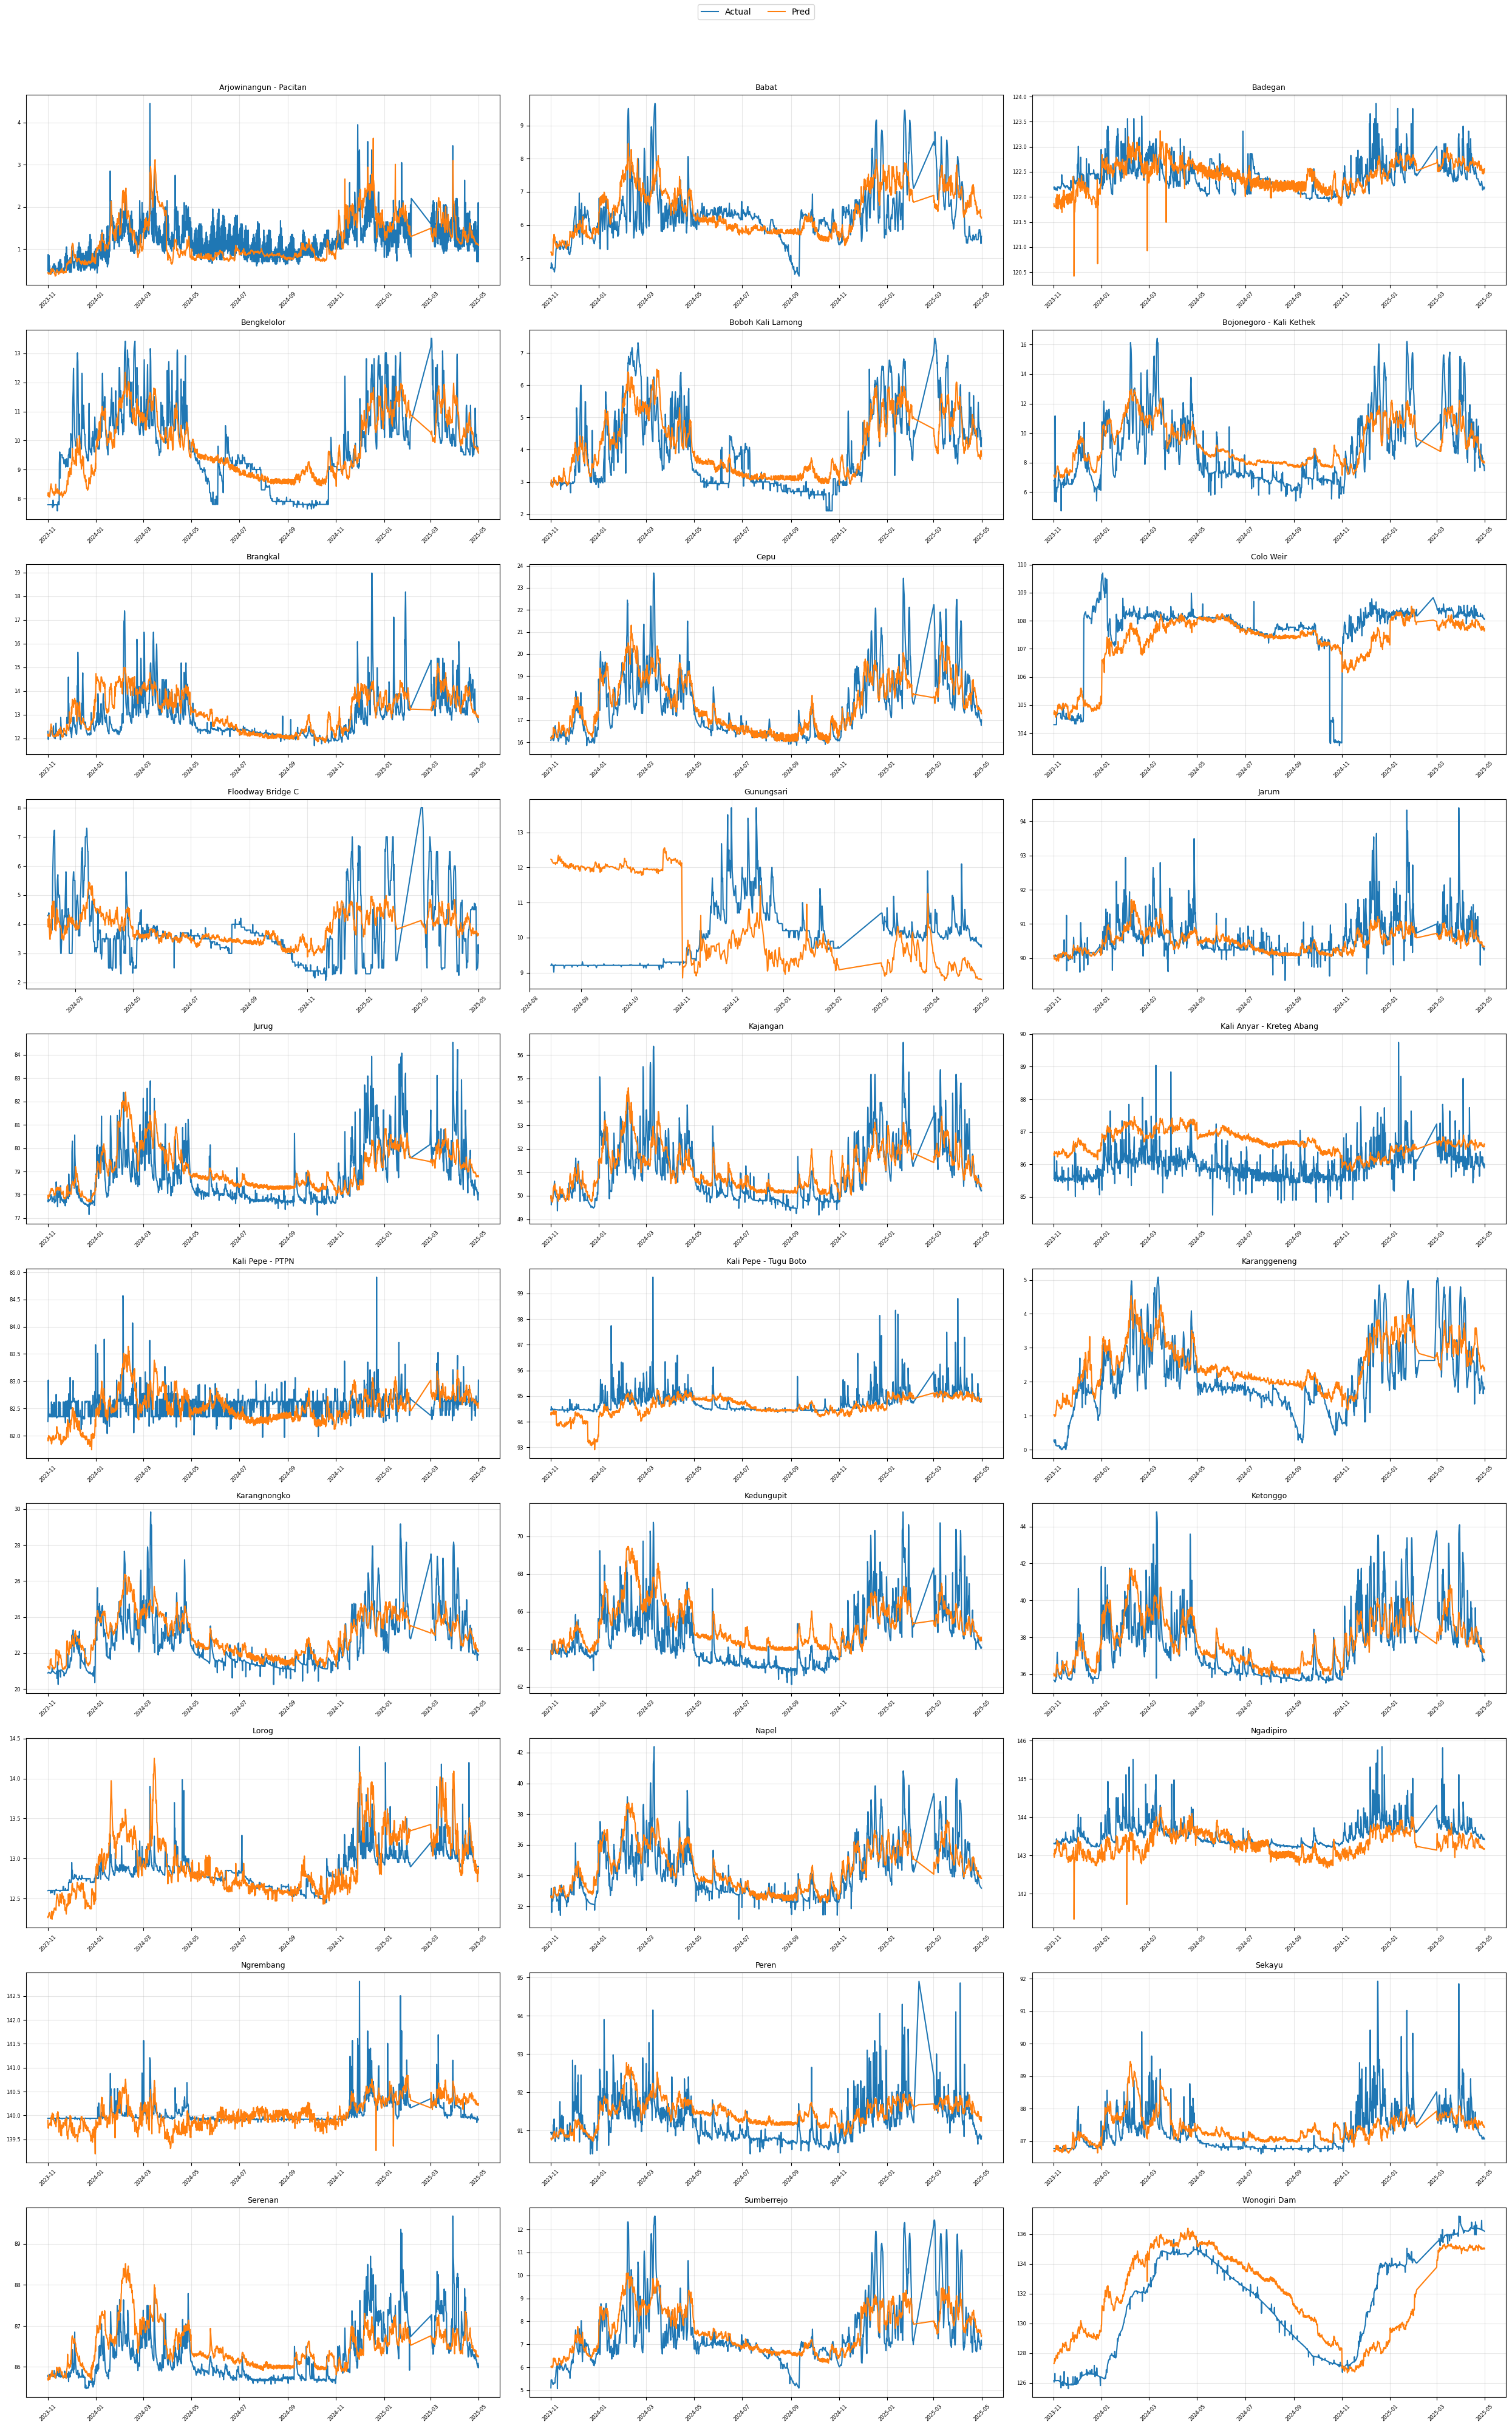

In [68]:
stations = sorted(pred_df["nama_pos"].unique())

ncols = 3      # ubah ke 5 kalau mau 5 per baris
nrows = math.ceil(len(stations) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(25, 4*nrows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    df_plot = (
        pred_df[pred_df["nama_pos"] == station]
        .sort_values("datetime")
    )

    ax.plot(
        df_plot["datetime"],
        df_plot["tma_mdpl"],
        color="tab:blue",
        linewidth=1.5,
        label="Actual"
    )

    ax.plot(
        df_plot["datetime"],
        df_plot["pred"],
        color="tab:orange",
        linewidth=1.5,
        label="Pred"
    )

    ax.set_title(station, fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=6)
    ax.tick_params(axis='y', labelsize=6)
    ax.grid(alpha=0.3)

# Hapus subplot kosong
for j in range(len(stations), len(axes)):
    fig.delaxes(axes[j])

# Legend cukup sekali
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

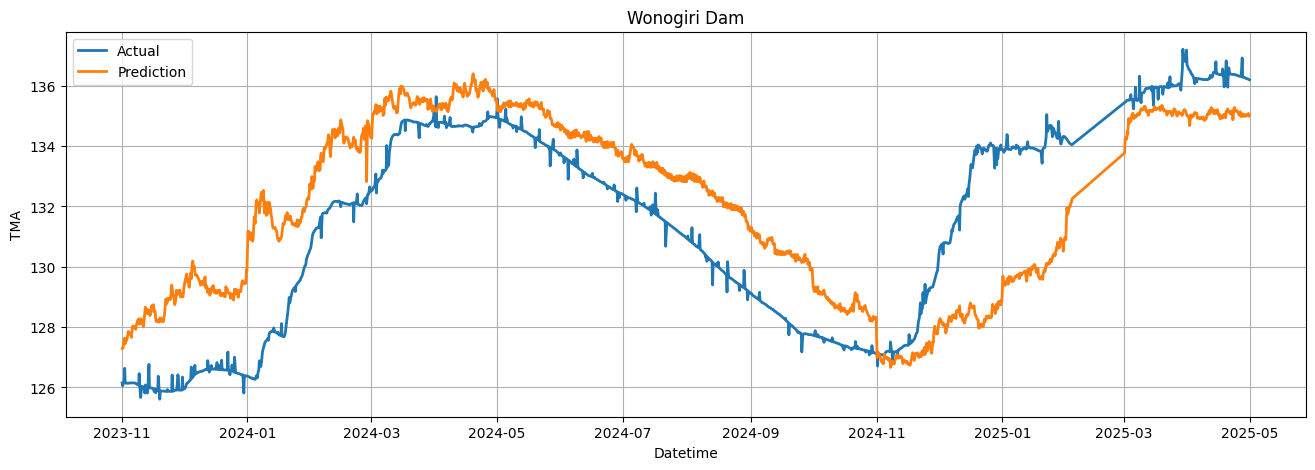

In [69]:
station = "Wonogiri Dam"

plot_df = pred_df[pred_df["nama_pos"] == station].sort_values("datetime")

plt.figure(figsize=(16,5))

plt.plot(
    plot_df["datetime"],
    plot_df["tma_mdpl"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_df["datetime"],
    plot_df["pred"],
    label="Prediction",
    linewidth=2
)

plt.title(station)
plt.xlabel("Datetime")
plt.ylabel("TMA")
plt.legend()
plt.grid(True)

plt.show()

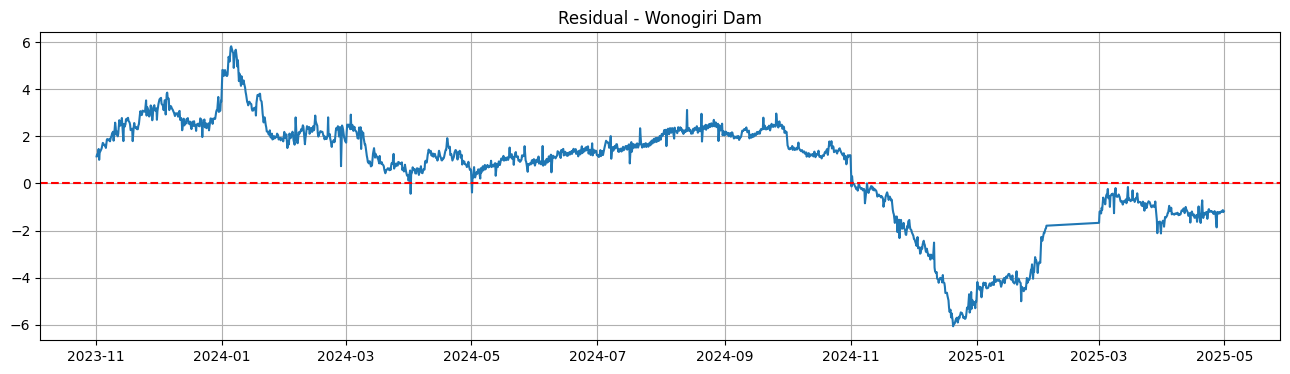

In [70]:
plt.figure(figsize=(16,4))

plt.plot(
    plot_df["datetime"],
    plot_df["error"]
)

plt.axhline(0,color="red",linestyle="--")

plt.title(f"Residual - {station}")
plt.grid(True)

plt.show()

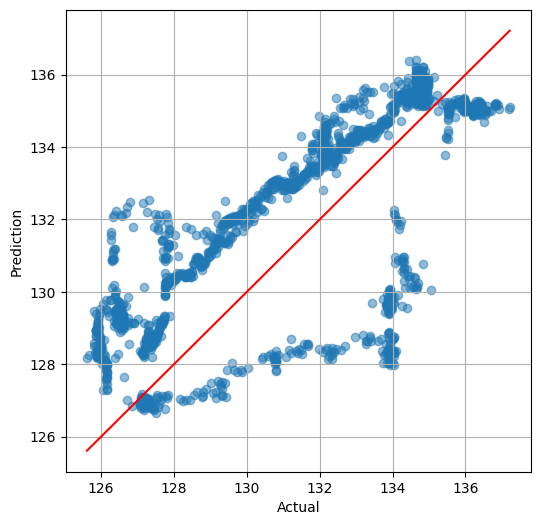

In [71]:
plt.figure(figsize=(6,6))

plt.scatter(
    plot_df["tma_mdpl"],
    plot_df["pred"],
    alpha=0.5
)

mn = min(plot_df["tma_mdpl"].min(), plot_df["pred"].min())
mx = max(plot_df["tma_mdpl"].max(), plot_df["pred"].max())

plt.plot(
    [mn,mx],
    [mn,mx],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Prediction")

plt.grid(True)

plt.show()

## Perbandingan XGB vs LGBM vs CatBoost

In [72]:
# comparison = pd.DataFrame({
#     'model': ['XGBoost', 'LightGBM', 'CatBoost'],
#     'RMSE_single_split': [rmse_xgb, rmse_lgbm, rmse_cat],
#     'RMSE_CV_mean': [np.mean(results_xgb), np.mean(results_lgbm), np.mean(results_cat)],
#     'RMSE_CV_std': [np.std(results_xgb), np.std(results_lgbm), np.std(results_cat)],
# })
# comparison['RMSE_CV_mean_pm_std'] = comparison.apply(
#     lambda r: f"{r['RMSE_CV_mean']:.4f} ± {r['RMSE_CV_std']:.4f}", axis=1
# )
# comparison_display = comparison[['model','RMSE_single_split','RMSE_CV_mean_pm_std']].sort_values('RMSE_single_split')
# print(comparison_display.to_string(index=False))
# comparison_display

## Voting Ensemble

In [73]:
# # ===== 1. cari bobot optimal & evaluasi di val_set dulu =====
# def neg_rmse_weighted(weights, preds_list, y_true):
#     w = np.array(weights) / np.sum(weights)
#     blend = sum(w_i * p for w_i, p in zip(w, preds_list))
#     return np.sqrt(mean_squared_error(y_true, blend))

# preds_list_val = [pred_val_cat, pred_val_xgb, pred_val_lgbm]
# res = minimize(neg_rmse_weighted, x0=[1,1,1], args=(preds_list_val, val_set['tma_mdpl'].values),
#                 method='Nelder-Mead', bounds=[(0,None)]*3)
# best_weights = np.array(res.x) / np.sum(res.x)
# print('Bobot optimal (cat, xgb, lgbm):', np.round(best_weights,3))

# pred_val_ensemble = (best_weights[0]*pred_val_cat +
#                       best_weights[1]*pred_val_xgb +
#                       best_weights[2]*pred_val_lgbm)

# rmse_val_ensemble = np.sqrt(mean_squared_error(val_set['tma_mdpl'], pred_val_ensemble))
# print(f'RMSE CatBoost saja   : {np.sqrt(mean_squared_error(val_set["tma_mdpl"], pred_val_cat)):.4f}')
# print(f'RMSE XGBoost saja    : {np.sqrt(mean_squared_error(val_set["tma_mdpl"], pred_val_xgb)):.4f}')
# print(f'RMSE LightGBM saja   : {np.sqrt(mean_squared_error(val_set["tma_mdpl"], pred_val_lgbm)):.4f}')
# print(f'RMSE Ensemble (bobot): {rmse_val_ensemble:.4f}')

In [74]:
# cutoffs = [
#     ('2024-09-01', '2025-03-03'),
#     ('2024-12-01', '2025-06-01'),
#     ('2025-03-03', '2025-09-18'),
# ]

# results_ensemble = []
# for train_end, val_end in cutoffs:
#     tr = train[train['datetime'] < train_end]
#     va = train[(train['datetime'] >= train_end) & (train['datetime'] < val_end)]

#     m_cat = CatBoostRegressor(**cat_params); m_cat.fit(tr[feature_cols], tr['tma_mdpl'])
#     m_xgb = XGBRegressor(**xgb_params); m_xgb.fit(tr[feature_cols], tr['tma_mdpl'])
#     m_lgbm = LGBMRegressor(**lgbm_params); m_lgbm.fit(tr[feature_cols], tr['tma_mdpl'])

#     p_cat = m_cat.predict(va[feature_cols])
#     p_xgb = m_xgb.predict(va[feature_cols])
#     p_lgbm = m_lgbm.predict(va[feature_cols])

#     p_ensemble = best_weights[0]*p_cat + best_weights[1]*p_xgb + best_weights[2]*p_lgbm
#     rmse = np.sqrt(mean_squared_error(va['tma_mdpl'], p_ensemble))
#     results_ensemble.append(rmse)
#     print(f'Fold RMSE ensemble: {rmse:.4f}')

# print(f'RMSE ensemble CV rata-rata: {np.mean(results_ensemble):.4f} +/- {np.std(results_ensemble):.4f}')

In [75]:
val_set = val_set.copy()
val_set['pred'] = cat.predict(val_set[feature_cols])  # ganti 'cat' sesuai model kamu

# RMSE per pos + NRMSE (dinormalisasi thd rentang tma pos itu sendiri, biar ADIL lintas skala)
per_pos = val_set.groupby('nama_pos').apply(
    lambda d: pd.Series({
        'rmse': np.sqrt(mean_squared_error(d['tma_mdpl'], d['pred'])),
        'tma_range': train_set[train_set['nama_pos']==d.name]['tma_mdpl'].max() - train_set[train_set['nama_pos']==d.name]['tma_mdpl'].min(),
        'n_baris': len(d),
    })
).reset_index()
per_pos['nrmse_pct'] = (per_pos['rmse'] / per_pos['tma_range']) * 100
per_pos = per_pos.sort_values('nrmse_pct', ascending=False)

print('=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===')
print(per_pos.head(10).to_string(index=False))
print()
print('=== 10 pos TERBAIK ===')
print(per_pos.tail(10).to_string(index=False))

=== 10 pos TERBURUK (NRMSE %, adil lintas skala) ===
                nama_pos     rmse  tma_range  n_baris  nrmse_pct
       Boboh Kali Lamong 1.246592   5.500000    600.0  22.665305
              Gunungsari 0.890402   4.682803    600.0  19.014301
       Floodway Bridge C 1.055714   5.924736    600.0  17.818760
             Bengkelolor 0.970074   5.934234    600.0  16.347078
                   Lorog 0.354343   2.350000    600.0  15.078418
            Wonogiri Dam 1.622285  11.710459    600.0  13.853298
                   Babat 0.684864   5.250000    586.0  13.045031
            Karanggeneng 0.618532   5.080000    600.0  12.175821
                 Badegan 0.243764   2.057899    600.0  11.845271
Bojonegoro - Kali Kethek 1.362022  11.687227    593.0  11.653938

=== 10 pos TERBAIK ===
                 nama_pos     rmse  tma_range  n_baris  nrmse_pct
Kali Anyar - Kreteg Abang 0.424559   5.299511    600.0   8.011285
                  Serenan 0.436459   5.510000    600.0   7.921218
          

C:\Users\leouw\AppData\Local\Temp\ipykernel_10160\3487094808.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pos = val_set.groupby('nama_pos').apply(


In [76]:
per_pos['total_se'] = per_pos['rmse']**2 * per_pos['n_baris']
per_pos['pct_of_total_se'] = per_pos['total_se'] / per_pos['total_se'].sum() * 100
per_pos_by_impact = per_pos.sort_values('total_se', ascending=False)

print('=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===')
print(per_pos_by_impact[['nama_pos','rmse','n_baris','total_se','pct_of_total_se']].head(10).to_string(index=False))
print(f'\n10 pos teratas ini menyumbang: {per_pos_by_impact.head(10)["pct_of_total_se"].sum():.1f}% dari total error')

=== Ranking berdasar KONTRIBUSI ke skor leaderboard ===
                nama_pos     rmse  n_baris    total_se  pct_of_total_se
            Wonogiri Dam 1.622285    600.0 1579.084954        14.656095
Bojonegoro - Kali Kethek 1.362022    593.0 1100.076935        10.210238
       Boboh Kali Lamong 1.246592    600.0  932.394626         8.653913
       Floodway Bridge C 1.055714    600.0  668.719788         6.206646
            Karangnongko 0.982271    600.0  578.913840         5.373122
             Bengkelolor 0.970074    600.0  564.626028         5.240512
                Ketonggo 0.968696    600.0  563.023574         5.225639
                   Napel 0.965777    600.0  559.635160         5.194189
              Gunungsari 0.890402    600.0  475.689692         4.415059
              Kedungupit 0.838006    600.0  421.352441         3.910734

10 pos teratas ini menyumbang: 69.1% dari total error


# Submission

In [ ]:
sample_weight_tr = np.where(train['musim_hujan']==1, 1.4, 1.0)
cat_final = CatBoostRegressor(**cat_params); cat_final.fit(train[feature_cols], train['tma_mdpl'], sample_weight=sample_weight_tr)
# xgb_final = XGBRegressor(**xgb_params); xgb_final.fit(train[feature_cols], train['tma_mdpl'])
# lgbm_final = LGBMRegressor(**lgbm_params); lgbm_final.fit(train[feature_cols], train['tma_mdpl'])

## XGB

In [ ]:
# test_pred = xgb_final.predict(test[feature_cols])
# submit_xgb = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
# submit_xgb.to_csv('outputs/submission_xgb.csv', index=False)

## LGBM

In [ ]:
# test_pred = lgbm_final.predict(test[feature_cols])
# submit_lgbm = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
# submit_lgbm.to_csv('outputs/submission_lgbm.csv', index=False)

## CatBoost

In [ ]:
test_pred = cat_final.predict(test[feature_cols])
submit_cat = pd.DataFrame({'id': test['id'], 'tma_mdpl': test_pred})
submit_cat.to_csv('outputs/submission_cat.csv', index=False)

## Ensemble Voting

In [ ]:
# pred_cat_test = cat_final.predict(test[feature_cols])
# pred_xgb_test = xgb_final.predict(test[feature_cols])
# pred_lgbm_test = lgbm_final.predict(test[feature_cols])

# final_pred = (best_weights[0]*pred_cat_test + best_weights[1]*pred_xgb_test + best_weights[2]*pred_lgbm_test)

# submit_ensemble = pd.DataFrame({'id': test['id'], 'tma_mdpl': final_pred})
# submit_ensemble.to_csv('outputs/submission_ensemble.csv', index=False)